In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if not (ROOT / "labels.csv").exists():
    ROOT = Path(".").resolve()

print("Project root:", ROOT)
print("labels.csv exists:", (ROOT / "labels.csv").exists())
print("images exists:", (ROOT / "images").exists())
print("edge_images exists:", (ROOT / "edge_images").exists())
print("sensors exists:", (ROOT / "sensors").exists())


Project root: C:\Users\ASUS\OneDrive\Music\matwi_fixed_config_10set_complete\matwi_fixed_config_10set
labels.csv exists: True
images exists: True
edge_images exists: True
sensors exists: True


In [12]:
df = pd.read_csv(ROOT / "labels.csv")

print("Total samples:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nSet distribution:")
print(df.groupby(["split", "Set"]).size())

print("\nWear statistics:")
print(df["wear_um"].describe())


Total samples: 600

Columns:
['Set', 'sequence', 'ImageName', 'wear_um', 'stage', 'stage_name', 'split', 'Vc', 'n', 'fz', 'Vf', 'Ae', 'Ap', 'material']

Split distribution:
split
train    360
val      120
test     120
Name: count, dtype: int64

Set distribution:
split  Set
test   9      60
       10     60
train  1      60
       2      60
       3      60
       4      60
       5      60
       6      60
val    7      60
       8      60
dtype: int64

Wear statistics:
count    600.000000
mean     107.500000
std       54.347833
min       15.000000
25%       61.250000
50%      107.500000
75%      153.750000
max      200.000000
Name: wear_um, dtype: float64


In [13]:
# Verify that every expected sample has an image and sensor file.

def image_path(row):
    return ROOT / "images" / row["ImageName"]

def edge_path(row):
    return ROOT / "edge_images" / row["ImageName"]

def sensor_path(row):
    return ROOT / "sensors" / (Path(row["ImageName"]).stem + ".npy")

df["image_exists"] = df.apply(lambda r: image_path(r).exists(), axis=1)
df["edge_exists"] = df.apply(lambda r: edge_path(r).exists(), axis=1)
df["sensor_exists"] = df.apply(lambda r: sensor_path(r).exists(), axis=1)

print("Images available:", int(df.image_exists.sum()), "/", len(df))
print("Edge crops available:", int(df.edge_exists.sum()), "/", len(df))
print("Sensors available:", int(df.sensor_exists.sum()), "/", len(df))

assert df.image_exists.all()
assert df.edge_exists.all()
assert df.sensor_exists.all()

print("\n✓ All samples have image, edge crop and sensor files.")


Images available: 600 / 600
Edge crops available: 600 / 600
Sensors available: 600 / 600

✓ All samples have image, edge crop and sensor files.


## 1. Image preprocessing


Full image: (224, 224) RGB
Edge crop : (224, 224) RGB
Full array: (224, 224, 3) float32 0.105882354 1.0
Edge array: (224, 224, 3) float32 0.105882354 1.0


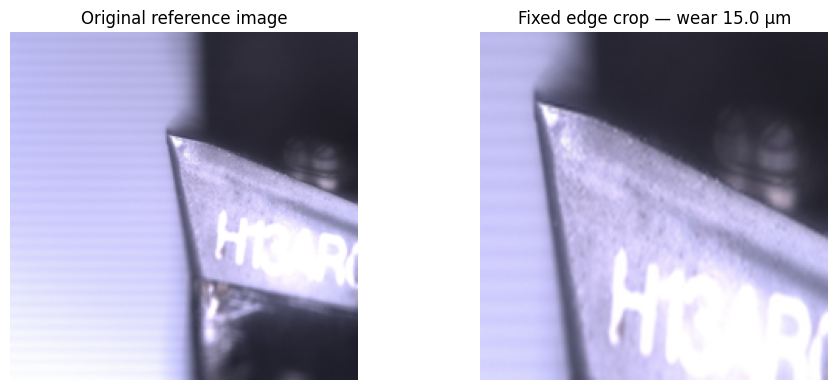

In [14]:
# Inspect image dimensions and demonstrate the preprocessing operation.

sample = df.iloc[len(df)//2]

full = Image.open(image_path(sample)).convert("RGB")
edge = Image.open(edge_path(sample)).convert("RGB")

print("Full image:", full.size, full.mode)
print("Edge crop :", edge.size, edge.mode)

full_arr = np.asarray(full, dtype=np.float32) / 255.0
edge_arr = np.asarray(edge, dtype=np.float32) / 255.0

print("Full array:", full_arr.shape, full_arr.dtype, full_arr.min(), full_arr.max())
print("Edge array:", edge_arr.shape, edge_arr.dtype, edge_arr.min(), edge_arr.max())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(full)
ax[0].set_title("Original reference image")
ax[0].axis("off")
ax[1].imshow(edge)
ax[1].set_title(f"Fixed edge crop — wear {sample.wear_um:.1f} µm")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 2. Sensor preprocessing

Each sample contains five sensor channels:

- acceleration
- acoustic signal
- Fx
- Fy
- Fz

Each sample is represented by **512 time points**.

The scaler is fitted using **training samples only** to avoid validation/test leakage.


In [15]:
SENSOR_CHANNELS = ["accel", "acoustic", "Fx", "Fy", "Fz"]
N_POINTS = 512

train_df = df[df["split"] == "train"].copy()

# First pass: calculate training-only mean/std over all sensor samples.
sensor_sum = np.zeros(5, dtype=np.float64)
sensor_sq_sum = np.zeros(5, dtype=np.float64)
sensor_count = 0

for _, row in train_df.iterrows():
    x = np.load(sensor_path(row)).astype(np.float64)
    assert x.shape == (5, N_POINTS), f"Unexpected shape: {x.shape}"
    sensor_sum += x.sum(axis=1)
    sensor_sq_sum += (x ** 2).sum(axis=1)
    sensor_count += x.shape[1]

sensor_mean = sensor_sum / sensor_count
sensor_var = np.maximum(sensor_sq_sum / sensor_count - sensor_mean**2, 1e-12)
sensor_std = np.sqrt(sensor_var)

print("Training sensor samples:", sensor_count)
print("Sensor mean:")
print(sensor_mean)
print("\nSensor std:")
print(sensor_std)


Training sensor samples: 184320
Sensor mean:
[ 1.47553218e-04  1.31575959e+00 -1.22501977e+00 -3.04983173e-01
 -3.70014174e+00]

Sensor std:
[0.03131352 0.74624697 0.48711978 0.13412176 1.11904783]


Raw shape   : (5, 512)
Scaled shape: (5, 512)
Scaled channel means: [-0.01181555 -1.66667706  1.693286    1.67847776  1.69807023]
Scaled channel stds : [0.25267438 0.02759363 0.10556955 0.16761578 0.07815939]


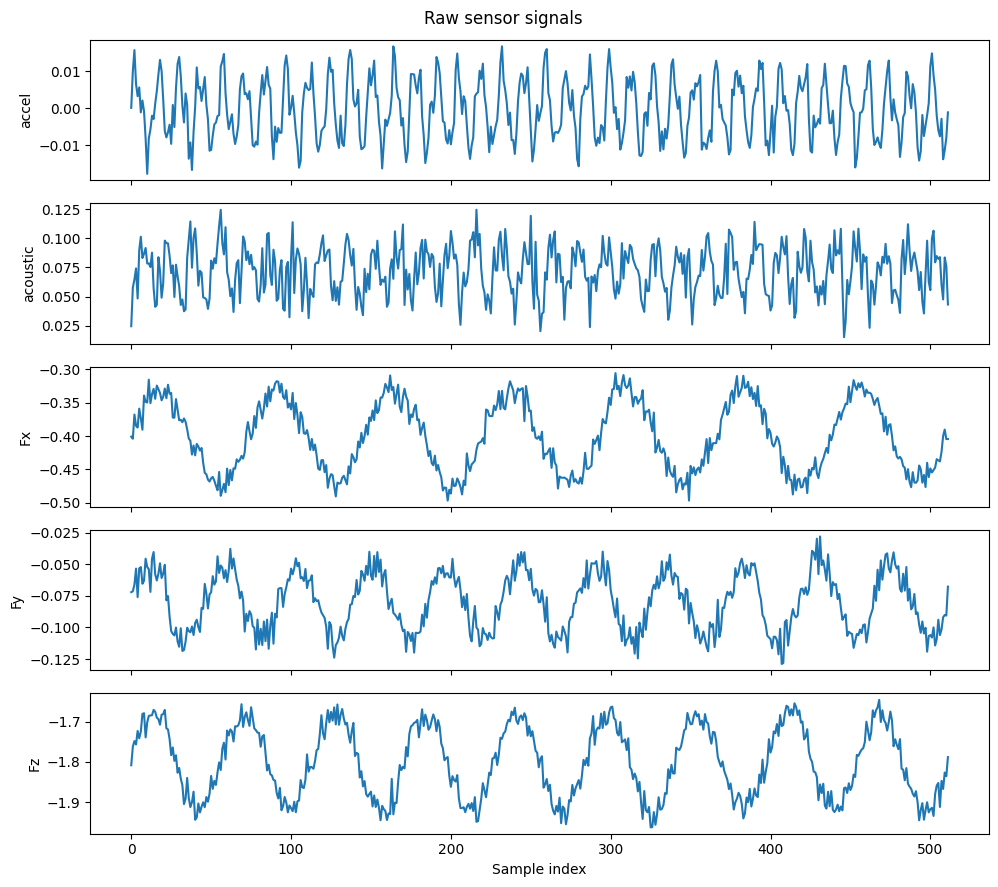

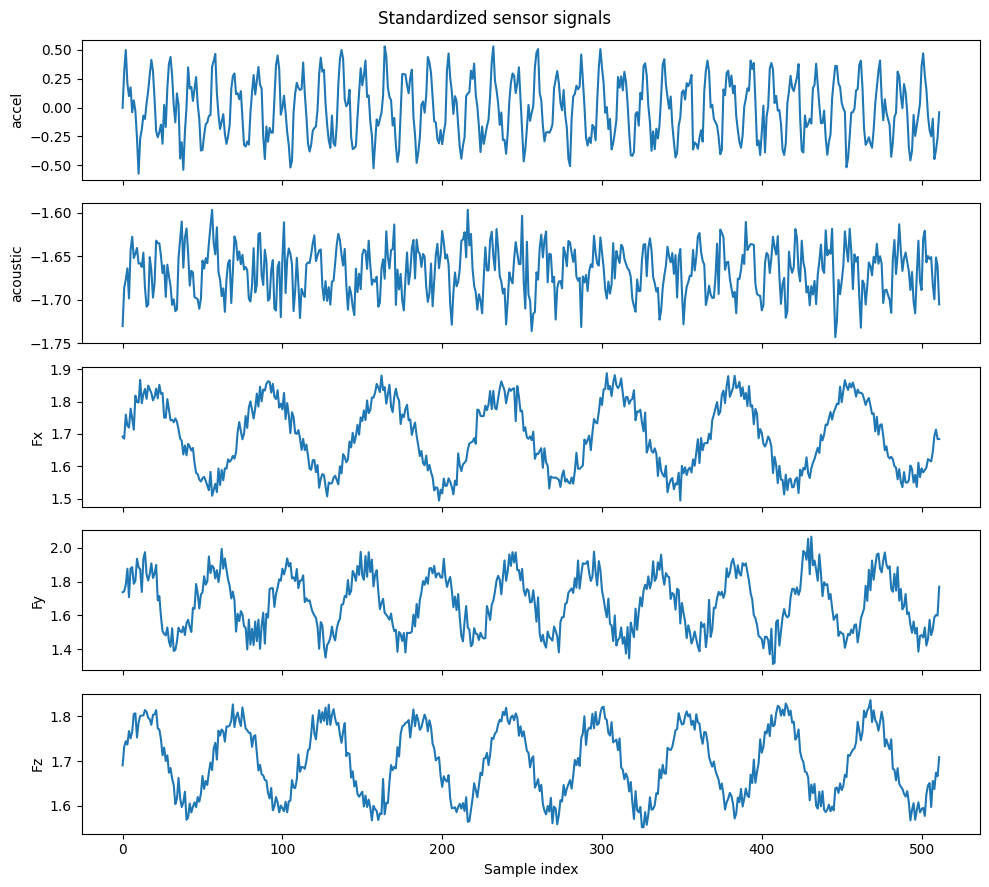

In [16]:
# Demonstrate standardization on one training sample.

r = train_df.iloc[0]
raw_sensor = np.load(sensor_path(r)).astype(np.float32)
scaled_sensor = (raw_sensor - sensor_mean[:, None]) / sensor_std[:, None]

print("Raw shape   :", raw_sensor.shape)
print("Scaled shape:", scaled_sensor.shape)
print("Scaled channel means:", scaled_sensor.mean(axis=1))
print("Scaled channel stds :", scaled_sensor.std(axis=1))

fig, axes = plt.subplots(5, 1, figsize=(10, 9), sharex=True)
for i, ch in enumerate(SENSOR_CHANNELS):
    axes[i].plot(raw_sensor[i])
    axes[i].set_ylabel(ch)
axes[-1].set_xlabel("Sample index")
plt.suptitle("Raw sensor signals")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 1, figsize=(10, 9), sharex=True)
for i, ch in enumerate(SENSOR_CHANNELS):
    axes[i].plot(scaled_sensor[i])
    axes[i].set_ylabel(ch)
axes[-1].set_xlabel("Sample index")
plt.suptitle("Standardized sensor signals")
plt.tight_layout()
plt.show()


## 3. Metadata preprocessing

Numerical machining parameters:

`Vc, n, fz, Vf, Ae, Ap`

are standardized using **training-set statistics only**.

Material is encoded:

- CK45 → 0
- RVS304 → 1


In [17]:
NUMERIC = ["Vc", "n", "fz", "Vf", "Ae", "Ap"]
MATERIAL_TO_IDX = {"CK45": 0, "RVS304": 1}

meta_mean = train_df[NUMERIC].astype(float).mean()
meta_std = train_df[NUMERIC].astype(float).std().replace(0, 1.0)

meta_scaled = train_df[NUMERIC].astype(float).copy()
meta_scaled = (meta_scaled - meta_mean) / meta_std

print("Training metadata mean:")
print(meta_mean)
print("\nTraining metadata std:")
print(meta_std)

print("\nScaled metadata summary:")
print(meta_scaled.describe().loc[["mean", "std"]])

print("\nMaterial encoding:")
print(MATERIAL_TO_IDX)


Training metadata mean:
Vc     146.289831
n     3207.875347
fz       0.050642
Vf     160.960755
Ae       1.000644
Ap       0.818492
dtype: float64

Training metadata std:
Vc     3.678184
n     20.635165
fz     0.000612
Vf     2.519778
Ae     0.003297
Ap     0.010940
dtype: float64

Scaled metadata summary:
                Vc             n            fz            Vf            Ae  \
mean -2.526374e-15  7.381750e-15  5.664605e-15  3.789561e-15 -1.117131e-14   
std   1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

                Ap  
mean  6.750156e-15  
std   1.000000e+00  

Material encoding:
{'CK45': 0, 'RVS304': 1}


## 4. Wear target preprocessing

Wear is a continuous regression target.

For model training, the target is standardized using the **training-set mean and standard deviation**:

`y_scaled = (wear - train_mean) / train_std`

Predictions can later be converted back to micrometers.


In [18]:
wear_mean = float(train_df["wear_um"].mean())
wear_std = float(train_df["wear_um"].std())

df["wear_scaled"] = (df["wear_um"] - wear_mean) / wear_std

print("Training wear mean:", wear_mean, "µm")
print("Training wear std :", wear_std, "µm")
print("\nScaled target summary:")
print(df[df.split=="train"]["wear_scaled"].describe())


Training wear mean: 107.5 µm
Training wear std : 54.37810176843301 µm

Scaled target summary:
count    3.600000e+02
mean    -2.960595e-17
std      1.000000e+00
min     -1.701052e+00
25%     -8.505262e-01
50%      0.000000e+00
75%      8.505262e-01
max      1.701052e+00
Name: wear_scaled, dtype: float64


## 5. Leakage checks

The following checks verify that preprocessing statistics come exclusively from the training split.

This is important because fitting scalers using validation/test data would leak information into the model-development process.


In [19]:
# Verify set-level split integrity.
sets_by_split = {
    split: set(df.loc[df["split"] == split, "Set"].unique())
    for split in ["train", "val", "test"]
}

print(sets_by_split)

assert sets_by_split["train"].isdisjoint(sets_by_split["val"])
assert sets_by_split["train"].isdisjoint(sets_by_split["test"])
assert sets_by_split["val"].isdisjoint(sets_by_split["test"])

print("No set appears in more than one split.")

# Verify metadata statistics are calculated only from train.
assert set(train_df["Set"].unique()) == set(range(1, 7))
print("✓ Metadata scaler uses Sets 01–06 only.")


{'train': {1, 2, 3, 4, 5, 6}, 'val': {8, 7}, 'test': {9, 10}}
No set appears in more than one split.
✓ Metadata scaler uses Sets 01–06 only.


In [20]:
# Save preprocessing artifacts for reproducibility.

artifacts = {
    "image_size": 224,
    "sensor_channels": SENSOR_CHANNELS,
    "sensor_points": N_POINTS,
    "sensor_scaler_mean": sensor_mean.tolist(),
    "sensor_scaler_std": sensor_std.tolist(),
    "metadata_columns": NUMERIC,
    "metadata_mean": meta_mean.tolist(),
    "metadata_std": meta_std.tolist(),
    "material_to_idx": MATERIAL_TO_IDX,
    "wear_mean": wear_mean,
    "wear_std": wear_std,
    "train_sets": sorted(train_df["Set"].unique().tolist()),
    "val_sets": sorted(df[df.split=="val"]["Set"].unique().tolist()),
    "test_sets": sorted(df[df.split=="test"]["Set"].unique().tolist()),
    "synthetic_benchmark": True
}

with open(ROOT / "preprocessing_artifacts.json", "w") as f:
    json.dump(artifacts, f, indent=2)

df[[
    "Set", "sequence", "ImageName", "wear_um", "stage", "stage_name",
    "split", "Vc", "n", "fz", "Vf", "Ae", "Ap", "material"
]].to_csv(ROOT / "processed_index.csv", index=False)

print("Saved:")
print(" - preprocessing_artifacts.json")
print(" - processed_index.csv")


Saved:
 - preprocessing_artifacts.json
 - processed_index.csv
